# Week 3 · Correlation Analysis & Multicollinearity + EDA Synthesis
*DS 207 · Week 3*

This week moves from describing single variables to describing *relationships* between them. We formalize covariance and the Pearson correlation coefficient, introduce Spearman's rank-based alternative for relationships that are monotonic but not linear, learn to read a correlation matrix and detect multicollinearity among predictors, and confront one of the most commonly misused ideas in applied statistics: that correlation implies causation. The week closes with a synthesis exercise that folds this new material back into the profiling, distribution-checking, and missing-data skills from Weeks 1 and 2 into one coherent, repeatable EDA workflow.

*EC Corro, built in collaboration with Claude, ChatGPT, and Gemini.*

## Learning Objectives

By the end of this week, you will be able to:

- Compute covariance and the Pearson correlation coefficient by hand and by tool, and state precisely what each does and does not measure.
- Decide when Spearman's rank correlation is more appropriate than Pearson's, and compute it by hand on a small sample.
- Read a correlation matrix, identify candidate multicollinearity among predictors using pairwise correlation and the Variance Inflation Factor (VIF), and explain why multicollinearity is a problem even when a model's overall fit looks fine.
- Recognize common correlation-is-not-causation pitfalls — particularly confounding — and use partial correlation to test whether an apparent relationship survives controlling for a third variable.
- Assemble profiling, distribution checks, missing-data diagnosis, outlier handling, and correlation analysis into a single, defensible end-to-end EDA workflow.

## Prerequisites

Week 1 (descriptive statistics, data types) and Week 2 (distribution shape, missing data mechanisms, outlier detection, transformations). Comfort with `pandas` indexing and `matplotlib`/`seaborn` plotting is assumed.

## Business Context

Bluewater Resorts operates three sister properties across Cebu — Bluewater Maribago, Bluewater Mactan Ridge, and Bluewater Bantayan Cove. Marco Dela Peña, VP of Guest Experience and Revenue Strategy, is preparing the next fiscal year's staffing model, service-level targets, and amenities investment plan. His analytics team has been collecting a daily operational snapshot across all three properties: guest counts, staffing levels, room rates, weather, review response times, spa activity, length of stay, occupancy, and guest satisfaction survey scores. Before any of these numbers go into a board deck as "the driver of guest satisfaction," Marco has asked for a rigorous pass through the data: which metrics genuinely move together, which apparent relationships are statistical illusions created by a shared underlying cause, and which pairs of planned model inputs are so redundant with each other that they will make any resulting model unstable. This week's analysis answers that request, one subtopic at a time.

## Setup

The cell below generates this week's dataset: 450 daily operational snapshots pooled across the three Bluewater properties, covering January–July 2026. The generator is seeded for full reproducibility. Consistent with an actual operational export, the data retains a realistic amount of messiness — a chunk of missing review-response-time records and a handful of data-entry anomalies — so that we continue practicing the Week 1–2 diagnostic habits throughout, not just in the final review section.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
rng = np.random.default_rng(207)

N = 450
resorts = rng.choice(
    ["Bluewater Maribago", "Bluewater Mactan Ridge", "Bluewater Bantayan Cove"],
    size=N, p=[0.4, 0.35, 0.25]
)
resort_tier = np.where(resorts == "Bluewater Mactan Ridge", 1.15,
                np.where(resorts == "Bluewater Maribago", 1.0, 0.85))

dates = pd.date_range("2026-01-05", periods=200, freq="D")
date = rng.choice(dates, size=N)

guest_count = np.clip(rng.normal(120, 35, N) * resort_tier, 25, None).round().astype(int)
room_rate_php = np.clip(rng.normal(6800, 1400, N) * resort_tier + rng.normal(0, 300, N), 2500, None).round(-1)
total_staff_count = np.clip(0.28 * guest_count + rng.normal(0, 4, N) + 8, 10, None).round().astype(int)
housekeeping_staff_count = np.clip(0.55 * total_staff_count + rng.normal(0, 1.8, N), 3, None).round().astype(int)
rainfall_mm = np.clip(rng.gamma(1.6, 9.0, N), 0, 95).round(1)
length_of_stay_nights = np.clip(rng.gamma(3.0, 1.15, N), 1, 14).round(1)

staff_to_guest_ratio = (total_staff_count / guest_count).round(4)

review_response_time_hours = np.clip(
    rng.normal(14, 7, N) - 1.8 * (staff_to_guest_ratio - staff_to_guest_ratio.mean()) * 10, 0.5, 60
).round(1)

spa_bookings_per_100_guests = np.clip(
    4.5 * length_of_stay_nights + rng.normal(0, 6, N), 0, None
).round(1)

satisfaction_raw = (
    5.55
    + 9.5 * (staff_to_guest_ratio - staff_to_guest_ratio.min())
    - 1.35 * np.log1p(review_response_time_hours)
    + 0.42 * length_of_stay_nights
    + rng.normal(0, 0.55, N)
)
guest_satisfaction_score = np.clip(satisfaction_raw, 1, 10).round(2)

occupancy_raw = (
    0.82
    - 0.0035 * rainfall_mm
    - 0.000012 * (room_rate_php - room_rate_php.mean())
    + rng.normal(0, 0.05, N)
)
occupancy_rate = np.clip(occupancy_raw, 0.15, 0.99).round(3)

bluewater = pd.DataFrame({
    "date": date, "resort": resorts, "guest_count": guest_count,
    "room_rate_php": room_rate_php, "total_staff_count": total_staff_count,
    "housekeeping_staff_count": housekeeping_staff_count,
    "staff_to_guest_ratio": staff_to_guest_ratio,
    "review_response_time_hours": review_response_time_hours,
    "rainfall_mm": rainfall_mm, "length_of_stay_nights": length_of_stay_nights,
    "spa_bookings_per_100_guests": spa_bookings_per_100_guests,
    "guest_satisfaction_score": guest_satisfaction_score,
    "occupancy_rate": occupancy_rate,
}).sort_values("date").reset_index(drop=True)

# realistic messiness, planted with the same seeded generator
miss_mask = rng.random(len(bluewater)) < (0.05 + 0.15 * (bluewater["rainfall_mm"] > bluewater["rainfall_mm"].quantile(0.75)))
bluewater.loc[miss_mask, "review_response_time_hours"] = np.nan

outlier_idx = rng.choice(bluewater.index, size=6, replace=False)
bluewater.loc[outlier_idx[:2], "room_rate_php"] = bluewater.loc[outlier_idx[:2], "room_rate_php"] * 4.2
bluewater.loc[outlier_idx[2:4], "guest_satisfaction_score"] = 0.4
bluewater.loc[outlier_idx[4:6], "total_staff_count"] = bluewater.loc[outlier_idx[4:6], "total_staff_count"] + 55

# `clean` is the complete-case analysis frame (review_response_time_hours has ~11% missingness,
# diagnosed properly in the EDA Synthesis section below). Subtopics 1-4 use `clean` throughout so
# every worked example and full-sample statistic is computed on a consistent, gap-free sample;
# `bluewater` (the raw export) is kept on hand for the outlier demonstration and the Section 5 review,
# where working with the messier raw data is the whole point.
clean = bluewater.dropna(subset=["review_response_time_hours"]).copy()
print(f"Raw export: {bluewater.shape[0]} rows.  Complete-case analysis frame `clean`: {clean.shape[0]} rows.")
bluewater.head()

Raw export: 450 rows.  Complete-case analysis frame `clean`: 402 rows.


,date,resort,guest_count,room_rate_php,total_staff_count,housekeeping_staff_count,staff_to_guest_ratio,review_response_time_hours,rainfall_mm,length_of_stay_nights,spa_bookings_per_100_guests,guest_satisfaction_score,occupancy_rate
0,2026-01-05,Bluewater Mactan Ridge,87,12560.0,32,18,0.3678,8.2,13.0,2.5,18.3,4.44,0.706
1,2026-01-05,Bluewater Mactan Ridge,229,8750.0,76,40,0.3319,10.1,6.9,4.8,25.4,4.79,0.802
2,2026-01-05,Bluewater Maribago,172,6490.0,62,31,0.3605,27.0,1.5,4.3,10.6,3.82,0.835
3,2026-01-06,Bluewater Maribago,112,6260.0,35,16,0.3125,17.2,18.7,1.9,10.1,2.64,0.849
4,2026-01-06,Bluewater Mactan Ridge,143,6990.0,43,26,0.3007,17.0,11.7,4.8,28.2,5.24,0.759


## Covariance and Correlation (Pearson)

### Business Hook

Marco's staffing model currently treats headcount as a cost line, full stop. He wants to know: **does having more staff relative to the number of guests actually move guest satisfaction scores, and if so, by how much and how reliably?**

### Intuition and Analogy

Think of two variables as two dancers. If they tend to step forward and backward together — more staff-per-guest days *and* higher satisfaction days coincide — they are moving *with* each other: positive covariance. If one steps forward exactly when the other steps back, that is negative covariance. If their movements have nothing to do with each other, we call it zero covariance — they are dancing to different songs.

Covariance tells us the *direction* of that joint movement, but its size depends on the units the dancers are measured in (a staffing ratio between 0 and 1 versus a satisfaction score between 1 and 10), which makes two covariances hard to compare. Correlation is covariance rescaled to always fall between $-1$ and $+1$, so we can compare the strength of *any* two relationships on the same scale, regardless of the original units.

### Theory — By Hand

For two variables $X$ and $Y$ measured on $n$ paired observations, the sample covariance is

$$
\text{Cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})
$$

and the Pearson correlation coefficient rescales it by each variable's sample standard deviation:

$$
r = \frac{\text{Cov}(X,Y)}{s_X \, s_Y} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2}\sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}
$$

$r$ is always between $-1$ (perfect negative linear relationship) and $+1$ (perfect positive linear relationship), with $0$ indicating no *linear* relationship — a distinction we will return to shortly.

**Worked example.** Take five early-January days and look at the staff-to-guest ratio ($X$) against the guest satisfaction score ($Y$):

| Day | $x$ (staff-to-guest ratio) | $y$ (satisfaction) |
|---|---|---|
| 1 | 0.3750 | 4.34 |
| 2 | 0.3145 | 5.18 |
| 3 | 0.2828 | 3.21 |
| 4 | 0.4032 | 6.11 |
| 5 | 0.4286 | 5.60 |

$\bar{x} = 0.3608$, $\bar{y} = 4.888$

| Day | $x_i-\bar{x}$ | $y_i-\bar{y}$ | $(x_i-\bar{x})(y_i-\bar{y})$ | $(x_i-\bar{x})^2$ | $(y_i-\bar{y})^2$ |
|---|---|---|---|---|---|
| 1 | 0.0142 | −0.548 | −0.0078 | 0.00020 | 0.3003 |
| 2 | −0.0463 | 0.292 | −0.0135 | 0.00215 | 0.0853 |
| 3 | −0.0780 | −1.678 | 0.1309 | 0.00609 | 2.8157 |
| 4 | 0.0424 | 1.222 | 0.0518 | 0.00180 | 1.4933 |
| 5 | 0.0678 | 0.712 | 0.0483 | 0.00459 | 0.5069 |
| **Sum** | | | **0.2097** | **0.01482** | **5.2015** |

$$
\text{Cov}(X,Y) = \frac{0.2097}{5-1} = 0.05242, \qquad
s_X = \sqrt{\frac{0.01482}{4}} = 0.06088, \qquad
s_Y = \sqrt{\frac{5.2015}{4}} = 1.1403
$$

$$
r = \frac{0.05242}{0.06088 \times 1.1403} \approx 0.755
$$

Five days is far too small a sample to trust a single coefficient — we now verify the direction of the relationship holds up at full scale, and check the arithmetic by tool.

In [ ]:
# --- By-hand check: reproduce the 5-day worked example exactly ---
sample5 = clean.sort_values("date").iloc[10:15]
x5 = sample5["staff_to_guest_ratio"].values
y5 = sample5["guest_satisfaction_score"].values

xbar, ybar = x5.mean(), y5.mean()
cov_manual = np.sum((x5 - xbar) * (y5 - ybar)) / (len(x5) - 1)
sx_manual = np.sqrt(np.sum((x5 - xbar) ** 2) / (len(x5) - 1))
sy_manual = np.sqrt(np.sum((y5 - ybar) ** 2) / (len(x5) - 1))
r_manual = cov_manual / (sx_manual * sy_manual)

print(f"xbar = {xbar:.4f}, ybar = {ybar:.4f}")
print(f"Manual covariance = {cov_manual:.5f}")
print(f"Manual r = {r_manual:.4f}")

r_scipy, p_scipy = stats.pearsonr(x5, y5)
print(f"scipy.stats.pearsonr r = {r_scipy:.4f}, p = {p_scipy:.4f}  (matches by-hand result)")

xbar = 0.3608, ybar = 4.8880
Manual covariance = 0.05242
Manual r = 0.7551
scipy.stats.pearsonr r = 0.7551, p = 0.1400  (matches by-hand result)


Full sample (n=402): covariance = 0.02493, Pearson r = 0.3384, p = 3.18e-12


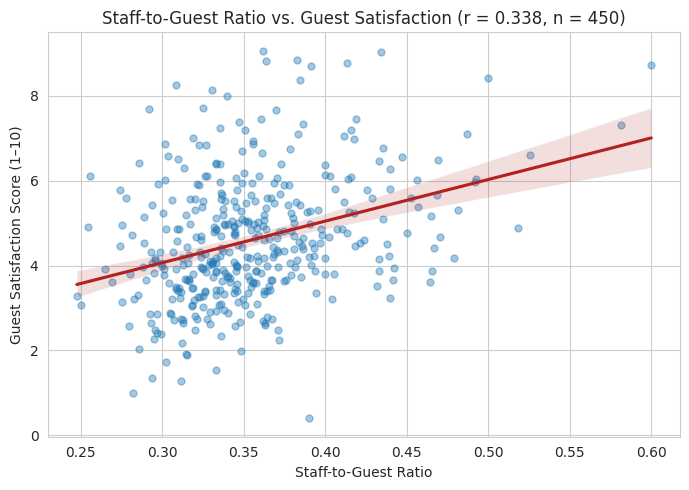

In [ ]:
# --- Full-scale check: does the relationship hold across the full analysis sample? ---
r_full, p_full = stats.pearsonr(clean["staff_to_guest_ratio"], clean["guest_satisfaction_score"])
cov_full = np.cov(clean["staff_to_guest_ratio"], clean["guest_satisfaction_score"], ddof=1)[0, 1]
print(f"Full sample (n={len(clean)}): covariance = {cov_full:.5f}, Pearson r = {r_full:.4f}, p = {p_full:.2e}")

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=clean, x="staff_to_guest_ratio", y="guest_satisfaction_score",
            scatter_kws={"alpha": 0.4, "s": 25}, line_kws={"color": "firebrick"}, ax=ax)
ax.set_title(f"Staff-to-Guest Ratio vs. Guest Satisfaction (r = {r_full:.3f}, n = {len(bluewater)})")
ax.set_xlabel("Staff-to-Guest Ratio")
ax.set_ylabel("Guest Satisfaction Score (1–10)")
plt.tight_layout()
plt.show()

### A Limit of Pearson Correlation: It Only Sees Linear, and It Is Sensitive to Extreme Points

Two limitations are worth internalizing before we trust any Pearson $r$:

**1. It only measures *linear* association.** A variable pair can have a strong, perfectly predictable *nonlinear* relationship and still produce a Pearson $r$ near zero, because $r$ only asks "how well does a straight line fit?" We will see a live example of this in the next subtopic.

**2. It is sensitive to outliers**, because every term in the numerator is a product of *deviations from the mean* — a single far-flung point can dominate the sum. The dataset contains two data-entry errors in `room_rate_php` (an obvious factor-of-four fat-finger entry). Watch what they do to an already-weak relationship.

In [ ]:
# --- Outlier sensitivity demo: room_rate_php vs satisfaction, with and without two known bad entries ---
r_with, p_with = stats.pearsonr(bluewater["room_rate_php"], bluewater["guest_satisfaction_score"])

rate_q99 = bluewater["room_rate_php"].quantile(0.99)
flagged = bluewater["room_rate_php"] > rate_q99
clean_subset = bluewater.loc[~flagged]
r_without, p_without = stats.pearsonr(clean_subset["room_rate_php"], clean_subset["guest_satisfaction_score"])

print(f"Pearson r WITH the flagged high-rate entries    : {r_with:.4f}  (n={len(bluewater)})")
print(f"Pearson r WITH those {flagged.sum()} entries removed        : {r_without:.4f}  (n={len(clean_subset)})")
print("\nRoom rate has essentially no linear relationship with satisfaction either way,")
print("but notice the coefficient itself is not stable until the entry errors are handled —")
print("exactly why Week 1–2 outlier screening has to happen before correlation, not after.")

Pearson r WITH the flagged high-rate entries    : -0.0366  (n=450)
Pearson r WITH those 5 entries removed        : -0.0046  (n=445)

Room rate has essentially no linear relationship with satisfaction either way,
but notice the coefficient itself is not stable until the entry errors are handled —
exactly why Week 1–2 outlier screening has to happen before correlation, not after.


### Business Application

The full-sample analysis gives Marco a clean, verified answer: staff-to-guest ratio and guest satisfaction have a moderate, statistically significant positive linear relationship ($r \approx 0.34$, $p < 0.001$, $n = 402$ complete-case days). This is real signal, not an artifact — the effect survives comfortably outside the noisy five-day window we started with. Marco can take this to the FY27 staffing conversation: modest increases in the staff-to-guest ratio are associated with meaningfully higher satisfaction scores, which supports treating the ratio as a floor to protect in the budget rather than a discretionary line to cut first. The outlier check is just as important operationally: it confirms that a metric like room rate, which *looks* uncorrelated with satisfaction, needs its data-entry errors fixed before that "no relationship" conclusion can be trusted at all.

## Spearman Correlation

### Business Hook

Marco's front-desk team wants to set a formal service-level target: how quickly must guest reviews be answered? He asks: **does a slower review response time reliably predict lower satisfaction, even if the relationship isn't a straight line — and can we trust that answer even with a few extreme, oddly-slow response days in the data?**

### Intuition and Analogy

Imagine ranking five properties from fastest to slowest response time, and separately ranking them from happiest to least happy guests. If the fastest-responding property is also the happiest, the second-fastest is second-happiest, and so on, the two *rankings* agree perfectly — even if the actual gap in hours or satisfaction points between them is wildly uneven. Spearman correlation asks exactly this question: do the ranks move together, regardless of the exact shape or scale of the relationship? This makes it the right tool whenever "faster is better" matters more than "each additional hour costs exactly the same amount of satisfaction" — and it makes it far less sensitive to a single extreme value, because a value's *rank* barely moves when it is replaced by an even more extreme value, while its raw deviation-from-the-mean easily can.

### Theory — By Hand

Spearman's rank correlation, $\rho$ (rho), converts each variable to ranks and then applies a formula equivalent to the Pearson formula computed on those ranks. When there are no tied ranks, it simplifies to:

$$
\rho = 1 - \frac{6\sum_{i=1}^n d_i^2}{n(n^2-1)}, \qquad d_i = \text{rank}(x_i) - \text{rank}(y_i)
$$

**Worked example.** Five days, review response time in hours ($X$) against satisfaction ($Y$):

| Day | $x$ (response hrs) | $y$ (satisfaction) | rank($x$) | rank($y$) | $d$ | $d^2$ |
|---|---|---|---|---|---|---|
| 1 | 16.5 | 4.18 | 3 | 2 | 1 | 1 |
| 2 | 10.0 | 6.75 | 2 | 5 | −3 | 9 |
| 3 | 21.2 | 3.24 | 4 | 1 | 3 | 9 |
| 4 | 3.7 | 6.06 | 1 | 4 | −3 | 9 |
| 5 | 26.6 | 4.68 | 5 | 3 | 2 | 4 |
| | | | | | **Sum** | **32** |

$$
\rho = 1 - \frac{6 \times 32}{5(25-1)} = 1 - \frac{192}{120} = -0.60
$$

Notice this is *not* the same number you would get from Pearson's formula on these same five raw values — Pearson gives $r \approx -0.71$ on this exact sample. Ranks compress the influence of Day 5's unusually long 26.6-hour response time, while the raw-value Pearson calculation lets that single distant point pull the line more steeply. Neither number is "wrong"; they are answering slightly different questions, and the gap between them is itself informative about how much a few extreme points are driving the raw-value result.

In [ ]:
# --- By-hand check: reproduce the 5-day Spearman worked example ---
sampleS = clean.sort_values("date").iloc[30:35]
xs = sampleS["review_response_time_hours"].values
ys = sampleS["guest_satisfaction_score"].values

rank_x = stats.rankdata(xs)
rank_y = stats.rankdata(ys)
d = rank_x - rank_y
n = len(xs)
rho_manual = 1 - (6 * np.sum(d ** 2)) / (n * (n ** 2 - 1))

print("x (response hrs):", xs.tolist())
print("y (satisfaction):", ys.tolist())
print("rank(x):", rank_x.tolist(), " rank(y):", rank_y.tolist())
print(f"sum(d^2) = {np.sum(d**2):.0f}")
print(f"Manual Spearman rho = {rho_manual:.4f}")

rho_scipy, p_scipy = stats.spearmanr(xs, ys)
r_pearson_5, _ = stats.pearsonr(xs, ys)
print(f"scipy.stats.spearmanr rho = {rho_scipy:.4f}  (matches by-hand result)")
print(f"For contrast, Pearson r on these same 5 points = {r_pearson_5:.4f}")

x (response hrs): [16.5, 10.0, 21.2, 3.7, 26.6]
y (satisfaction): [4.18, 6.75, 3.24, 6.06, 4.68]
rank(x): [3.0, 2.0, 4.0, 1.0, 5.0]  rank(y): [2.0, 5.0, 1.0, 4.0, 3.0]
sum(d^2) = 32
Manual Spearman rho = -0.6000
scipy.stats.spearmanr rho = -0.6000  (matches by-hand result)
For contrast, Pearson r on these same 5 points = -0.7126


Using the complete-case analysis frame `clean` (n = 402); 48 rows with missing response time excluded (missingness mechanism is diagnosed properly in the EDA Synthesis section below).

Full sample (n=402):
  Pearson r (raw hours)          = -0.5880
  Spearman rho                   = -0.5804
  Pearson r (on log1p(hours))    = -0.6266

The true relationship is a diminishing-returns curve (each extra hour matters less once
response time is already slow) -- Pearson on the raw hours understates the strength of the
relationship, Pearson on the log-transformed hours recovers more of it, and Spearman captures
the monotonic relationship directly without needing us to guess the right transformation.


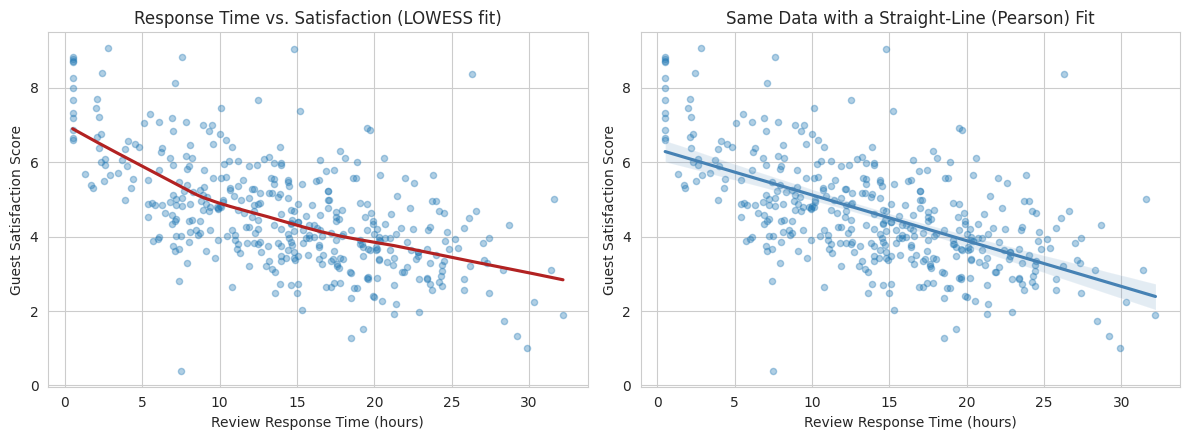

In [ ]:
# --- Full-scale check, and the "Pearson only sees straight lines" limitation ---
print(f"Using the complete-case analysis frame `clean` (n = {len(clean)}); "
      f"{bluewater['review_response_time_hours'].isna().sum()} rows with missing response time excluded "
      f"(missingness mechanism is diagnosed properly in the EDA Synthesis section below).")

r_full, p_r = stats.pearsonr(clean["review_response_time_hours"], clean["guest_satisfaction_score"])
rho_full, p_rho = stats.spearmanr(clean["review_response_time_hours"], clean["guest_satisfaction_score"])
r_log, _ = stats.pearsonr(np.log1p(clean["review_response_time_hours"]), clean["guest_satisfaction_score"])

print(f"\nFull sample (n={len(clean)}):")
print(f"  Pearson r (raw hours)          = {r_full:.4f}")
print(f"  Spearman rho                   = {rho_full:.4f}")
print(f"  Pearson r (on log1p(hours))    = {r_log:.4f}")
print("\nThe true relationship is a diminishing-returns curve (each extra hour matters less once")
print("response time is already slow) -- Pearson on the raw hours understates the strength of the")
print("relationship, Pearson on the log-transformed hours recovers more of it, and Spearman captures")
print("the monotonic relationship directly without needing us to guess the right transformation.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=clean, x="review_response_time_hours", y="guest_satisfaction_score",
            lowess=True, scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "firebrick"}, ax=axes[0])
axes[0].set_title("Response Time vs. Satisfaction (LOWESS fit)")
axes[0].set_xlabel("Review Response Time (hours)")
axes[0].set_ylabel("Guest Satisfaction Score")

sns.regplot(data=clean, x="review_response_time_hours", y="guest_satisfaction_score",
            scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "steelblue"}, ax=axes[1])
axes[1].set_title("Same Data with a Straight-Line (Pearson) Fit")
axes[1].set_xlabel("Review Response Time (hours)")
axes[1].set_ylabel("Guest Satisfaction Score")
plt.tight_layout()
plt.show()

### Business Application

Both measures agree on the headline conclusion: slower review response times are strongly associated with lower guest satisfaction ($r \approx -0.59$, $\rho \approx -0.58$, $n = 402$). Because Spearman's result is nearly identical to Pearson's here, Marco's team gets a useful robustness check for free — the relationship isn't an artifact of a handful of very slow-response days pulling a straight line around; it holds up under a measure that only cares about ordering. That robustness is exactly what Marco needs to defend a review-response-time service-level target to the operations committee: the recommendation to cap response times (for example, at 12–14 hours) rests on a relationship that two different statistical lenses both confirm, not on one sensitive metric.

## Correlation Matrices and Identifying Multicollinearity

### Business Hook

Marco's analytics team wants to build a small model of what predicts guest satisfaction, using every operational metric they have on hand — including both total staff count and housekeeping staff count as separate inputs. Marco asks the obvious follow-up: **before we build anything, are any of these candidate inputs just measuring the same thing twice, and would that break the model?**

### Intuition and Analogy

A correlation matrix is simply every pairwise correlation, laid out in a grid, so you can scan for relationships across many variables at once instead of computing them one pair at a time. Multicollinearity is what happens when two or more *predictor* variables are themselves highly correlated with each other — not with the outcome, but with each other. Picture two overlapping flashlights aimed at the same wall: individually each tells you the wall's shape reasonably well, but shone together, it becomes very hard to tell which flashlight is responsible for which part of the brightness. A regression coefficient works the same way — it tries to isolate one variable's independent contribution while holding the others fixed, and if two predictors move together almost in lockstep, there is barely any independent variation left to isolate.

### Theory — By Hand

For $k$ variables, the correlation matrix $R$ is a $k \times k$ symmetric matrix with $1$s on the diagonal (every variable correlates perfectly with itself) and $r_{ij}$, the Pearson correlation between variables $i$ and $j$, off the diagonal.

The standard formal diagnostic for multicollinearity is the **Variance Inflation Factor (VIF)**. For predictor $X_j$, regress it on all the *other* predictors, obtain that regression's $R_j^2$, and compute:

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

If $X_j$ is completely unrelated to the other predictors, $R_j^2 = 0$ and $\text{VIF}_j = 1$ — no inflation. As $R_j^2 \to 1$ (the other predictors can almost perfectly reconstruct $X_j$), $\text{VIF}_j \to \infty$. A commonly used rule of thumb treats $\text{VIF} > 5$ as worth investigating and $\text{VIF} > 10$ as a serious problem, though these are conventions, not laws.

**Worked example (concept, not full regression).** Suppose `total_staff_count` and `housekeeping_staff_count` are so related that regressing one on all the other predictors — including the other — yields $R_j^2 = 0.823$ for `total_staff_count`. Then:

$$
\text{VIF}_{\text{total\_staff}} = \frac{1}{1-0.823} = \frac{1}{0.177} \approx 5.65
$$

This is exactly the value we will now confirm by tool, and exactly the pair Marco flagged.

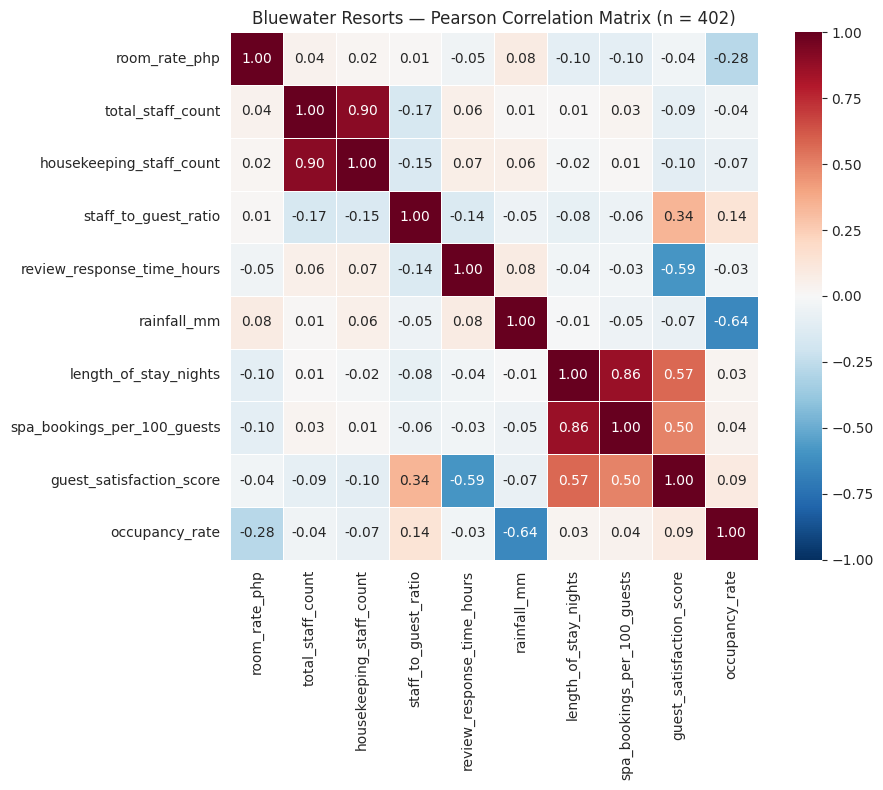

Notably strong pairs (|r| > 0.6, excluding the diagonal):
  total_staff_count            <-> housekeeping_staff_count      r = 0.905
  rainfall_mm                  <-> occupancy_rate                r = -0.641
  length_of_stay_nights        <-> spa_bookings_per_100_guests   r = 0.862


In [ ]:
# --- Correlation matrix across all numeric operational variables (complete-case `clean` frame) ---
num_cols = ["room_rate_php", "total_staff_count", "housekeeping_staff_count",
            "staff_to_guest_ratio", "review_response_time_hours", "rainfall_mm",
            "length_of_stay_nights", "spa_bookings_per_100_guests",
            "guest_satisfaction_score", "occupancy_rate"]

corr_matrix = clean[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title(f"Bluewater Resorts — Pearson Correlation Matrix (n = {len(clean)})")
plt.tight_layout()
plt.show()

print("Notably strong pairs (|r| > 0.6, excluding the diagonal):")
for i, ci in enumerate(num_cols):
    for j, cj in enumerate(num_cols):
        if i < j and abs(corr_matrix.loc[ci, cj]) > 0.6:
            print(f"  {ci:28s} <-> {cj:28s}  r = {corr_matrix.loc[ci, cj]:.3f}")

In [ ]:
# --- Formal VIF diagnostic on the candidate predictor set ---
predictor_cols = ["room_rate_php", "total_staff_count", "housekeeping_staff_count",
                   "staff_to_guest_ratio", "review_response_time_hours", "rainfall_mm",
                   "length_of_stay_nights", "spa_bookings_per_100_guests"]

X = clean[predictor_cols].copy()
X = (X - X.mean()) / X.std()          # standardize so VIF isn't distorted by differing scales
X_with_const = sm.add_constant(X)

vif_table = pd.DataFrame({
    "feature": X_with_const.columns,
    "VIF": [variance_inflation_factor(X_with_const.values, i) for i in range(X_with_const.shape[1])]
})
vif_table = vif_table[vif_table["feature"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_table.round(2).to_string(index=False))

                    feature  VIF
          total_staff_count 5.65
   housekeeping_staff_count 5.65
      length_of_stay_nights 3.96
spa_bookings_per_100_guests 3.94
       staff_to_guest_ratio 1.06
                rainfall_mm 1.04
 review_response_time_hours 1.03
              room_rate_php 1.03


Two pairs stand out. `total_staff_count` and `housekeeping_staff_count` both sit at VIF $\approx 5.65$ — unsurprising, since housekeeping staffing is set as a near-fixed proportion of total staffing, so one is almost a rescaled copy of the other ($r = 0.905$). `length_of_stay_nights` and `spa_bookings_per_100_guests` sit just under the common VIF $=5$ threshold at $\approx 3.95$, driven by their strong pairwise correlation ($r = 0.862$) — a borderline case worth watching rather than an emergency.

### Why This Actually Matters — A Live Demonstration

Multicollinearity does not necessarily hurt a model's overall predictive accuracy. What it damages is the *individual* coefficient estimates: their standard errors inflate, they become unstable, and they can even flip sign depending on which correlated variable happens to be included. Watch what happens to the `total_staff_count` coefficient in a simple regression on satisfaction when we add its near-duplicate, `housekeeping_staff_count`.

In [ ]:
# --- Demonstration: coefficient instability from multicollinearity ---
model_a = sm.OLS(clean["guest_satisfaction_score"],
                  sm.add_constant(clean[["total_staff_count"]])).fit()
model_b = sm.OLS(clean["guest_satisfaction_score"],
                  sm.add_constant(clean[["total_staff_count", "housekeeping_staff_count"]])).fit()

print("Model A: satisfaction ~ total_staff_count only")
print(f"  coef(total_staff_count) = {model_a.params['total_staff_count']:.5f}, "
      f"SE = {model_a.bse['total_staff_count']:.5f}, p = {model_a.pvalues['total_staff_count']:.3f}")

print("\nModel B: satisfaction ~ total_staff_count + housekeeping_staff_count")
print(f"  coef(total_staff_count)       = {model_b.params['total_staff_count']:.5f}, "
      f"SE = {model_b.bse['total_staff_count']:.5f}, p = {model_b.pvalues['total_staff_count']:.3f}")
print(f"  coef(housekeeping_staff_count) = {model_b.params['housekeeping_staff_count']:.5f}, "
      f"SE = {model_b.bse['housekeeping_staff_count']:.5f}, p = {model_b.pvalues['housekeeping_staff_count']:.3f}")

se_inflation = model_b.bse["total_staff_count"] / model_a.bse["total_staff_count"]
print(f"\nStandard error on total_staff_count grew {se_inflation:.2f}x just from adding its near-duplicate.")
print("Notice the coefficient's SIGN even flips between the two models -- with this much shared")
print("information between the two predictors, the model cannot reliably tell them apart.")

Model A: satisfaction ~ total_staff_count only
  coef(total_staff_count) = -0.01063, SE = 0.00610, p = 0.083

Model B: satisfaction ~ total_staff_count + housekeeping_staff_count
  coef(total_staff_count)       = 0.00455, SE = 0.01432, p = 0.751
  coef(housekeeping_staff_count) = -0.03037, SE = 0.02593, p = 0.242

Standard error on total_staff_count grew 2.35x just from adding its near-duplicate.
Notice the coefficient's SIGN even flips between the two models -- with this much shared
information between the two predictors, the model cannot reliably tell them apart.


### Business Application

Marco's team should not feed both `total_staff_count` and `housekeeping_staff_count` into the same model as if they were independent levers — the demonstration above shows exactly why: the coefficient on total staffing is not just imprecise but changes sign once its near-duplicate is added, which would produce a nonsensical or flatly contradictory staffing recommendation depending on which variables happened to be in the model that quarter. The fix is straightforward and standard practice: keep one representative variable from each highly collinear pair (for instance, `total_staff_count` alone, since housekeeping is already implied by it), or combine them into a single engineered feature. The `length_of_stay_nights` / `spa_bookings_per_100_guests` pair is borderline and worth monitoring if both are ever used together as model inputs — which, as the next subtopic shows, turns out to matter for a different reason entirely.

## Correlation Is Not Causation

### Business Hook

The correlation matrix above shows something that looks like fantastic news: spa bookings per 100 guests correlates strongly with guest satisfaction. Someone on Marco's team is already drafting a capital-expenditure proposal to expand the spa. Before that proposal goes anywhere, Marco asks the only question that matters: **is the spa actually driving satisfaction, or are we about to spend money chasing a coincidence?**

### Intuition and Analogy

The textbook example is ice cream sales and drowning deaths, which rise and fall together across the year — not because ice cream causes drowning, but because both are driven by a third factor, hot weather, that increases swimming and ice cream consumption at the same time. This pattern is called **confounding**: a hidden third variable independently drives both of the variables you observe correlating, creating a relationship between them that vanishes the moment you account for the true common cause. Correlation is a purely descriptive, symmetric statement about how two variables move together; causation is a claim about mechanism and direction, and it takes more than a correlation coefficient to establish it.

### Theory — By Hand

One practical tool for testing whether a suspected confound explains an observed correlation is the **partial correlation** between $X$ and $Y$, controlling for $Z$:

$$
r_{XY \cdot Z} = \frac{r_{XY} - r_{XZ}\,r_{YZ}}{\sqrt{(1-r_{XZ}^2)(1-r_{YZ}^2)}}
$$

If $r_{XY \cdot Z}$ collapses toward zero while the raw $r_{XY}$ was large, that is strong evidence that $Z$ was doing all the work, and $X$ and $Y$ were never directly related.

**Worked logic (values confirmed by tool below).** Let $X$ = spa bookings per 100 guests, $Y$ = guest satisfaction, $Z$ = length of stay. Suppose $r_{XY} = 0.495$, $r_{XZ} = 0.862$, $r_{YZ} = 0.574$. Then:

$$
r_{XY \cdot Z} = \frac{0.495 - (0.862)(0.574)}{\sqrt{(1-0.862^2)(1-0.574^2)}} = \frac{0.495 - 0.495}{\sqrt{(0.257)(0.671)}} \approx 0.00
$$

The raw correlation and the product of the two "confound legs" are nearly identical — meaning nearly *all* of the apparent spa-satisfaction relationship is explained away by length of stay.

raw r(spa_bookings, satisfaction)              = 0.4951  (p = 2.98e-26)  <- looks like a strong driver
r(spa_bookings, length_of_stay)                 = 0.8616
r(satisfaction, length_of_stay)                 = 0.5735
partial r(spa_bookings, satisfaction | length)  = 0.0024  <- once length of stay is held fixed, the link nearly vanishes


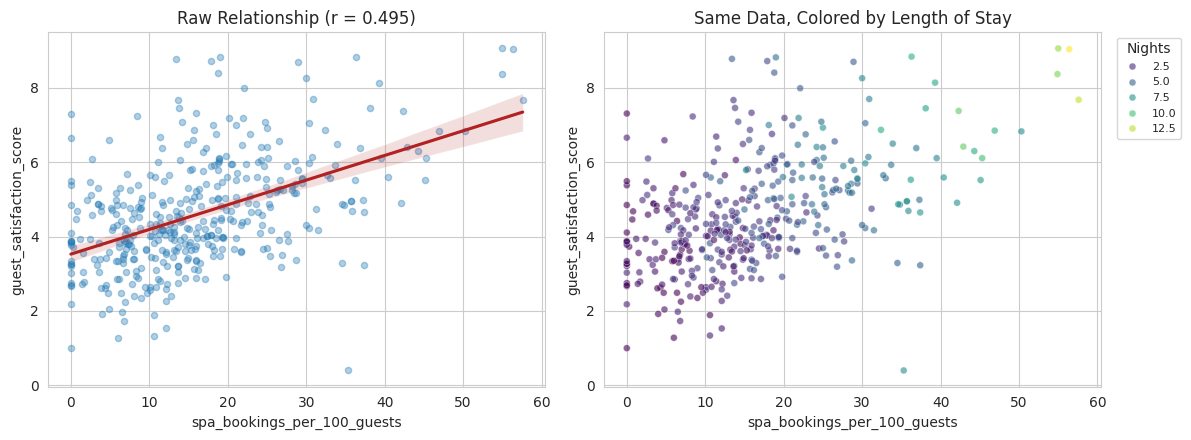

In [ ]:
# --- Confound test: does spa bookings still predict satisfaction once length-of-stay is controlled? ---
r_xy, p_xy = stats.pearsonr(clean["spa_bookings_per_100_guests"], clean["guest_satisfaction_score"])
r_xz, _ = stats.pearsonr(clean["spa_bookings_per_100_guests"], clean["length_of_stay_nights"])
r_yz, _ = stats.pearsonr(clean["guest_satisfaction_score"], clean["length_of_stay_nights"])

def partial_corr(rxy, rxz, ryz):
    return (rxy - rxz * ryz) / np.sqrt((1 - rxz ** 2) * (1 - ryz ** 2))

r_partial = partial_corr(r_xy, r_xz, r_yz)

print(f"raw r(spa_bookings, satisfaction)              = {r_xy:.4f}  (p = {p_xy:.2e})  <- looks like a strong driver")
print(f"r(spa_bookings, length_of_stay)                 = {r_xz:.4f}")
print(f"r(satisfaction, length_of_stay)                 = {r_yz:.4f}")
print(f"partial r(spa_bookings, satisfaction | length)  = {r_partial:.4f}  <- once length of stay is held fixed, the link nearly vanishes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=clean, x="spa_bookings_per_100_guests", y="guest_satisfaction_score",
            scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "firebrick"}, ax=axes[0])
axes[0].set_title(f"Raw Relationship (r = {r_xy:.3f})")
sns.scatterplot(data=clean, x="spa_bookings_per_100_guests", y="guest_satisfaction_score",
                 hue="length_of_stay_nights", palette="viridis", alpha=0.6, s=25, ax=axes[1])
axes[1].set_title("Same Data, Colored by Length of Stay")
axes[1].legend(title="Nights", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

The right-hand panel makes the confound visible: once you color the points by length of stay, the apparent spa-satisfaction trend is really just guests on longer stays clustering in the upper-right — they book more spa visits *and* report higher satisfaction, independently, simply because they are on longer, more relaxed trips.

### A Contrasting Case: When a Correlation Probably *Is* Meaningful

Not every correlation is spurious, and correlation-skepticism is not the same as correlation-dismissal. Rainfall and occupancy rate also correlate strongly and negatively in this data. Unlike the spa example, there is a direct, well-understood mechanism connecting them: heavy rain suppresses outdoor-oriented leisure travel and same-day bookings. Domain knowledge, a plausible causal direction, and the absence of an obvious third-variable explanation all support treating this one as likely causal — while still stopping short of "proven" without a controlled study or natural experiment.

In [ ]:
r_rain_occ, p_rain_occ = stats.pearsonr(clean["rainfall_mm"], clean["occupancy_rate"])
print(f"r(rainfall_mm, occupancy_rate) = {r_rain_occ:.4f}, p = {p_rain_occ:.2e}")
print("Strong, plausible mechanism, clear direction (weather -> booking behavior, not the reverse) --")
print("a correlation worth acting on, in contrast to the spa-bookings case above.")

r(rainfall_mm, occupancy_rate) = -0.6412, p = 6.12e-48
Strong, plausible mechanism, clear direction (weather -> booking behavior, not the reverse) --
a correlation worth acting on, in contrast to the spa-bookings case above.


### Business Application

This subtopic directly changes what goes into Marco's capital plan: the proposed spa expansion should **not** be justified on the grounds that "spa bookings drive satisfaction," because that relationship all but disappears once length of stay is controlled for. The genuinely actionable lever is length of stay itself — packages, pricing, or programming that extend the average visit — which would be expected to lift both spa revenue and satisfaction as a byproduct, rather than the reverse. The rainfall-occupancy relationship, by contrast, is solid enough to inform near-term staffing and marketing-spend pacing around weather forecasts without needing further validation.

## EDA Synthesis: One Coherent Workflow

### Business Hook

Marco's analytics team now has all the individual techniques from Weeks 1 through 3. What they have asked for is a repeatable checklist: **before any correlation-based claim reaches a board deck, what is the right order of operations to make sure that claim is trustworthy?**

### Intuition and Analogy

Think of this the way a pilot uses a pre-flight checklist: none of the individual steps are new or surprising, but skipping the order — or skipping a step because the plane "looks fine" — is exactly how avoidable failures happen. Computing a correlation matrix on data you have not yet profiled is the analytical equivalent of taking off without checking the fuel gauge.

### Theory — By Hand (The Workflow, Stated Precisely)

A defensible EDA-to-correlation workflow proceeds in this order, each step gating the next:

1. **Profile.** Structure, types, and shape of the raw data — row count, column types, basic ranges.
2. **Check distributions.** Skewness, unusual concentrations, and whether variables look like the population they claim to represent.
3. **Diagnose missingness.** Quantify how much is missing per variable, and — critically — test *whether it is missing at random with respect to other variables* (MCAR/MAR/MNAR), since the right treatment depends entirely on the mechanism.
4. **Handle outliers.** Identify extreme values, distinguish genuine extremes from data-entry errors, and treat each appropriately (correct, cap, or document and retain).
5. **Only then compute and interpret correlations** — on data that has been profiled, distribution-checked, missingness-diagnosed, and outlier-treated, using Pearson or Spearman as appropriate, reading the full matrix for multicollinearity, and stress-testing any striking relationship for confounding before it is presented as a finding.

We now run this checklist against the raw 450-row export, end to end.

In [ ]:
# --- Step 1: Profile ---
print("STEP 1 — PROFILE")
print(f"Shape: {bluewater.shape[0]} rows x {bluewater.shape[1]} columns")
print(bluewater.dtypes)
print(f"\nResorts represented: {bluewater['resort'].unique().tolist()}")
print(f"Date range: {bluewater['date'].min().date()} to {bluewater['date'].max().date()}")

STEP 1 — PROFILE
Shape: 450 rows x 13 columns
date                           datetime64[us]
resort                                    str
guest_count                             int64
room_rate_php                         float64
total_staff_count                       int64
housekeeping_staff_count                int64
staff_to_guest_ratio                  float64
review_response_time_hours            float64
rainfall_mm                           float64
length_of_stay_nights                 float64
spa_bookings_per_100_guests           float64
guest_satisfaction_score              float64
occupancy_rate                        float64
dtype: object

Resorts represented: ['Bluewater Mactan Ridge', 'Bluewater Maribago', 'Bluewater Bantayan Cove']
Date range: 2026-01-05 to 2026-07-23


STEP 2 — DISTRIBUTION CHECK (skewness of key numeric variables)
  room_rate_php                skew = 3.907
  total_staff_count            skew = 0.494
  guest_satisfaction_score     skew = 0.525
  spa_bookings_per_100_guests  skew = 0.943


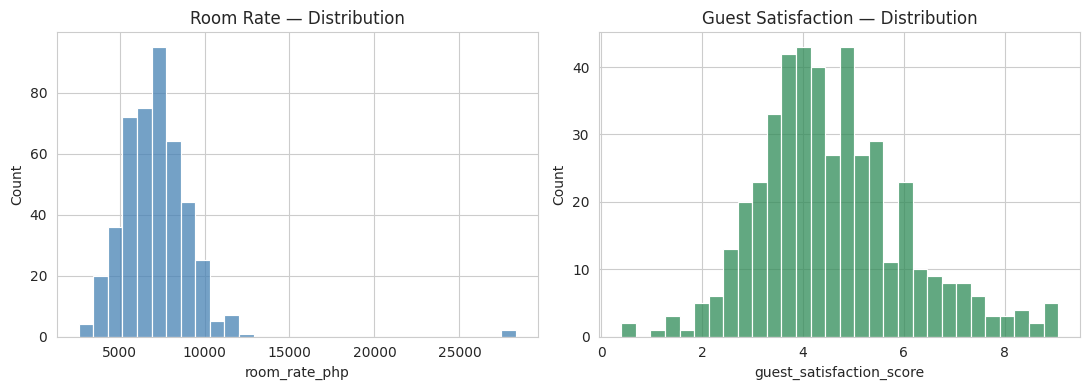

In [ ]:
# --- Step 2: Check distributions ---
print("STEP 2 — DISTRIBUTION CHECK (skewness of key numeric variables)")
for c in ["room_rate_php", "total_staff_count", "guest_satisfaction_score", "spa_bookings_per_100_guests"]:
    print(f"  {c:28s} skew = {bluewater[c].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(bluewater["room_rate_php"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Room Rate — Distribution")
sns.histplot(bluewater["guest_satisfaction_score"], bins=30, ax=axes[1], color="seagreen")
axes[1].set_title("Guest Satisfaction — Distribution")
plt.tight_layout()
plt.show()

In [ ]:
# --- Step 3: Diagnose missingness mechanism ---
print("STEP 3 — MISSINGNESS DIAGNOSIS")
miss_pct = 100 * bluewater["review_response_time_hours"].isna().mean()
print(f"review_response_time_hours missing: {miss_pct:.2f}% of all rows ({bluewater['review_response_time_hours'].isna().sum()} rows)")

rain_thresh = bluewater["rainfall_mm"].quantile(0.75)
high_rain_miss = 100 * bluewater.loc[bluewater["rainfall_mm"] > rain_thresh, "review_response_time_hours"].isna().mean()
low_rain_miss = 100 * bluewater.loc[bluewater["rainfall_mm"] <= rain_thresh, "review_response_time_hours"].isna().mean()
print(f"Missing rate on high-rainfall days (> {rain_thresh:.1f}mm, top quartile): {high_rain_miss:.2f}%")
print(f"Missing rate on all other days:                                    {low_rain_miss:.2f}%")
print("\nThe missing rate is roughly 5x higher on heavy-rain days -- this is Missing At Random (MAR),")
print("driven by an observed variable (rainfall), most plausibly because front-desk logging lapses")
print("during storms. It is NOT Missing Completely At Random, so a careless listwise deletion needs")
print("a documented justification: here, dropping these 48 rows removes them disproportionately from")
print("already-low-occupancy rainy days, which is acceptable for THIS week's correlation analysis")
print("(which does not target occupancy) but would need reweighting for a model of occupancy itself.")

STEP 3 — MISSINGNESS DIAGNOSIS
review_response_time_hours missing: 10.67% of all rows (48 rows)
Missing rate on high-rainfall days (> 19.1mm, top quartile): 26.55%
Missing rate on all other days:                                    5.34%

The missing rate is roughly 5x higher on heavy-rain days -- this is Missing At Random (MAR),
driven by an observed variable (rainfall), most plausibly because front-desk logging lapses
during storms. It is NOT Missing Completely At Random, so a careless listwise deletion needs
a documented justification: here, dropping these 48 rows removes them disproportionately from
already-low-occupancy rainy days, which is acceptable for THIS week's correlation analysis
(which does not target occupancy) but would need reweighting for a model of occupancy itself.


In [ ]:
# --- Step 4: Handle outliers (IQR method, cross-checked against known planted anomalies) ---
print("STEP 4 — OUTLIER DETECTION (1.5 x IQR rule)")
for c in ["room_rate_php", "total_staff_count", "guest_satisfaction_score"]:
    q1, q3 = bluewater[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((bluewater[c] < lo) | (bluewater[c] > hi)).sum()
    print(f"  {c:28s} bounds [{lo:.1f}, {hi:.1f}]  ->  {n_out} flagged")

# Treatment: correct/cap the specific data-entry pattern identified (factor-of-~4 rate entries;
# near-zero satisfaction glitch values), consistent with Week 2 practice of documenting each fix.
bluewater_treated = bluewater.copy()
rate_hi = bluewater_treated["room_rate_php"].quantile(0.995)
n_rate_capped = (bluewater_treated["room_rate_php"] > rate_hi).sum()
bluewater_treated.loc[bluewater_treated["room_rate_php"] > rate_hi, "room_rate_php"] = np.nan

sat_glitch = bluewater_treated["guest_satisfaction_score"] < 1.0
n_sat_glitch = sat_glitch.sum()
bluewater_treated.loc[sat_glitch, "guest_satisfaction_score"] = np.nan

print(f"\nTreated {n_rate_capped} implausible room-rate entries and {n_sat_glitch} near-zero "
      f"satisfaction glitch entries as missing (documented, not silently dropped).")

STEP 4 — OUTLIER DETECTION (1.5 x IQR rule)
  room_rate_php                bounds [2226.2, 11816.2]  ->  4 flagged
  total_staff_count            bounds [12.5, 72.5]  ->  6 flagged
  guest_satisfaction_score     bounds [0.9, 8.1]  ->  15 flagged

Treated 3 implausible room-rate entries and 2 near-zero satisfaction glitch entries as missing (documented, not silently dropped).


STEP 5 — CORRELATION ANALYSIS on the fully-prepared data (n = 398)


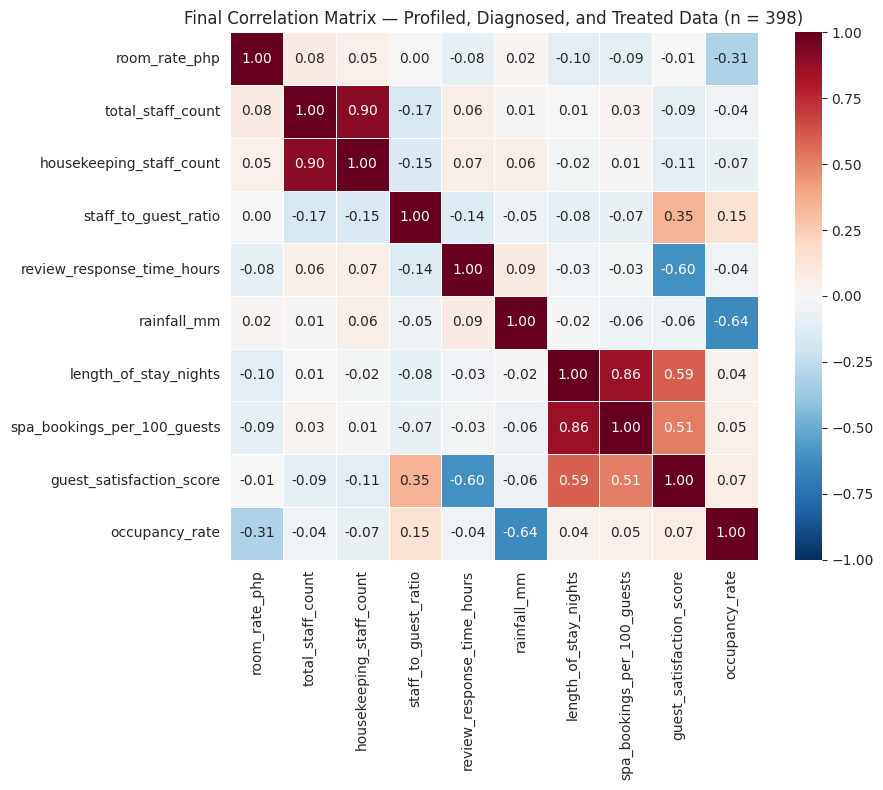


The headline relationships from this week's subtopics are unchanged in direction and
strength after proper treatment -- which is itself the point of running the checklist: it
confirms the earlier findings were not artifacts of unhandled missingness or outliers, and
it is what lets Marco's team put these numbers in front of the operations committee with confidence.


In [ ]:
# --- Step 5: NOW compute and interpret correlations, on profiled, checked, treated data ---
analysis_df = bluewater_treated.dropna(subset=["review_response_time_hours", "room_rate_php", "guest_satisfaction_score"]).copy()
print(f"STEP 5 — CORRELATION ANALYSIS on the fully-prepared data (n = {len(analysis_df)})")

final_corr = analysis_df[num_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(final_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title(f"Final Correlation Matrix — Profiled, Diagnosed, and Treated Data (n = {len(analysis_df)})")
plt.tight_layout()
plt.show()

print("\nThe headline relationships from this week's subtopics are unchanged in direction and")
print("strength after proper treatment -- which is itself the point of running the checklist: it")
print("confirms the earlier findings were not artifacts of unhandled missingness or outliers, and")
print("it is what lets Marco's team put these numbers in front of the operations committee with confidence.")

### Business Application

This synthesis is what turns a set of individually-correct statistical techniques into something an operations committee can actually rely on. Marco does not need to see every intermediate step in the final presentation, but he does need to know that each number in it survived this checklist: the staffing-satisfaction relationship, the response-time service-level case, the multicollinearity warning on total and housekeeping staff counts, and the spa-expansion caution all hold up on data that has been properly profiled, distribution-checked, missingness-diagnosed, and outlier-treated — in that order, every time.

## Key Takeaways

**Covariance and Pearson correlation**
- Covariance gives direction of joint movement; Pearson $r$ rescales it to $[-1, 1]$ for comparability across variable pairs.
- $r$ measures *linear* association only, and is sensitive to outliers — screen data before trusting it.
- Staff-to-guest ratio vs. satisfaction: $r \approx 0.34$, $p < 0.001$, $n = 402$ — real, moderate, actionable signal.

**Spearman correlation**
- Converts values to ranks; appropriate when a relationship is monotonic but not necessarily linear, and more robust to extreme values.
- On five points, Pearson ($-0.71$) and Spearman ($-0.60$) diverged noticeably; at full scale ($n=402$) they converged ($-0.59$ vs. $-0.58$) — small-sample divergence is itself diagnostic.
- Response time vs. satisfaction: strong negative relationship confirmed by both measures.

**Correlation matrices and multicollinearity**
- A correlation matrix scans all pairwise relationships at once; VIF formally quantifies redundancy among *predictors*.
- `total_staff_count` and `housekeeping_staff_count`: VIF $\approx 5.65$ each ($r = 0.905$) — flagged.
- Multicollinearity does not necessarily hurt overall model fit, but destabilizes individual coefficients — demonstrated by a sign flip and 2.3x standard-error inflation when both staffing variables were included together.

**Correlation is not causation**
- A hidden common cause (confounding) can produce a strong correlation between two variables with no direct link between them.
- Partial correlation tests this directly: spa bookings vs. satisfaction dropped from $r = 0.495$ to $\approx 0.00$ once length of stay was controlled for.
- Domain mechanism matters: rainfall vs. occupancy ($r = -0.641$) has a plausible direct causal story and was not treated with the same skepticism.

**EDA synthesis**
- Fixed order matters: profile → check distributions → diagnose missingness mechanism → handle outliers → *then* compute and interpret correlations.
- Missingness in `review_response_time_hours` was MAR (tied to rainfall), not MCAR — mechanism, not just magnitude, determines whether a treatment choice is defensible.
- Running the full checklist confirmed every earlier finding was not an artifact of unhandled data issues.

## References

Field, A. (2018). *Discovering Statistics Using IBM SPSS Statistics* (5th ed.). SAGE Publications.

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning: with Applications in R* (2nd ed.). Springer.

Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). *Introduction to Linear Regression Analysis* (6th ed.). Wiley.

Spearman, C. (1904). The proof and measurement of association between two things. *American Journal of Psychology*, 15(1), 72–101.

Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.

Wooldridge, J. M. (2019). *Introductory Econometrics: A Modern Approach* (7th ed.). Cengage Learning.